In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score
from preprocessing import get_features_and_target
from visualizer import plot_visualizer, plot_visualizer_classification
import plotly.graph_objects as go
from sklearn.model_selection import StratifiedKFold
from preprocessing import get_features_and_target_classification
from tabpfn import TabPFNClassifier, TabPFNRegressor
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
import huggingface_hub
huggingface_hub.login()

# Getting Dataframe

In [3]:
# Load the training and development datasets
train_df = pd.read_csv("data/train_data.csv")
dev_df = pd.read_csv("data/development_data.csv")
#sc = StandardScaler()

target_column_nugget = "NuggetDiameter (mm)" 
target_column_class = "Category" 


x_train, y_train = get_features_and_target(train_df, target_column_nugget)
x_dev, y_dev = get_features_and_target(dev_df, target_column_nugget)


# Fit Nugget Estimator


In [4]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train)

# Predict on the test set
predictions_nugget_train = regressor.predict(x_train)
predictions_nugget_dev= regressor.predict(x_dev)


In [5]:
y_train

0      2.63
1      3.34
2      2.76
3      2.57
4      4.72
       ... 
271    4.30
272    4.33
273    4.35
274    3.58
275    3.50
Name: NuggetDiameter (mm), Length: 276, dtype: float64

In [6]:
predictions_nugget_train

array([2.6384141, 3.8812337, 2.678266 , 2.715414 , 4.06826  , 2.6459665,
       3.9218059, 3.6440105, 2.6730807, 3.6668258, 3.961673 , 2.6658273,
       2.8094845, 2.6549196, 2.694228 , 3.8703237, 2.6830616, 4.1422606,
       4.1280203, 4.134412 , 4.112897 , 4.102205 , 4.110785 , 4.1092415,
       4.1218038, 4.117892 , 4.1155734, 4.116135 , 3.8689642, 3.8709755,
       3.9127235, 3.7690063, 3.793705 , 3.775341 , 3.7206583, 3.5098507,
       3.4730554, 3.497253 , 3.4820344, 3.4762077, 3.4545255, 3.4436312,
       3.448555 , 3.4431877, 3.4463427, 3.322708 , 3.3202424, 3.326467 ,
       3.320572 , 3.3176513, 3.328565 , 3.3220272, 3.3180668, 3.3200178,
       3.3291206, 3.3191872, 3.3249674, 3.322247 , 3.3148856, 3.3252504,
       3.3211207, 3.3203056, 3.32061  , 3.327844 , 3.3234751, 3.3282223,
       3.3173347, 3.3204875, 3.3298535, 3.324159 , 3.3276463, 3.3220377,
       3.3235242, 3.3283374, 3.328339 , 3.327571 , 3.3413014, 3.3481052,
       3.3402107, 3.3372962, 3.3360486, 3.3406491, 

# Add Physical Columns Interfacial_Failure and Pullout_Failure

In [7]:
def compute_interfacial_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     f_pull = 1 * (np.pi/4) * (nugget_prediction)**2 * (0.7 * 365) 
     return np.round(f_pull, 1) 

def compute_pullout_failure(df, nugget_prediction):
     t = df[['Thickness A (mm)', 'Thickness B (mm)']].min(axis=1).iloc[0] 
     x = df[['Thickness A (mm)', 'Thickness B (mm)']].sum(axis=1).iloc[0]
     # x can be approximated to metal sheet thickness. Change 2*t either to t to use the thinner 
     # metal sheet or 2*x to test if the sum of both metal sheets give beter results
     f_pull = np.pi * ((nugget_prediction) + 2*t)*t*365 
     return np.round(f_pull, 1) 

# Fit Model

In [8]:
# Target value

x_train, y_train = get_features_and_target(train_df, target_column_class)
x_dev, y_dev = get_features_and_target(dev_df, target_column_class)

classifier = TabPFNClassifier() 

classifier.fit(x_train,y_train)

predictions_class_train = classifier.predict(x_train)
predictions_class_dev = classifier.predict(x_dev)



# Add Pullforce as Target

In [9]:
def compute_pullforces(x, y, predictions_class, predictions_nugget):
    pullforces = []

    for sample_id, pred, nugget_value in zip(y.index, predictions_class, predictions_nugget):
        row_x_df = x.loc[[sample_id]]  # 1-row DataFrame

        if pred == "Bad":
            value = compute_interfacial_failure(row_x_df, nugget_value)
        else:
            value = compute_pullout_failure(row_x_df, nugget_value)

        pullforces.append(value)

    return np.array(pullforces)


In [10]:
pullforces_train = compute_pullforces(x_train, y_train, predictions_class_train, predictions_nugget_train)
pullforces_dev = compute_pullforces(x_dev, y_dev, predictions_class_dev, predictions_nugget_dev)


In [11]:
y_train_Regressor = train_df.groupby("Sample ID")['PullTest (N)'].first()
y_dev_Regressor = dev_df.groupby("Sample ID")['PullTest (N)'].first()

In [12]:
print(pullforces_dev)

[5799.3        1397.5        1399.69995117 1431.19995117 6017.9
 1469.30004883 3864.7        3935.5        3951.6        3966.8
 3512.1        3598.         3498.7        3470.9        3453.
 3221.6        3268.7        3413.7        3341.4        3321.4
 3264.8        3342.         3286.4        3310.7        3322.7
 3361.3        3359.7        3351.5        3255.2        3246.9
 3226.4        3292.9        3319.9        3384.4        3392.4
 3255.2        3287.5        3358.3        3239.1        3369.1
 3328.1        3618.8        3535.7        3573.9        3576.1
 3573.7        3615.6        3538.2        3495.4        3453.5
 3562.8        3565.         3539.5        3524.7        3520.9
 3548.3        3470.5        3509.2        3542.3        3533.3
 3488.5        3338.9        3334.9        3298.3        3263.7
 3306.7        3413.3        3349.3        3343.8        3359.4
 3301.7        3323.6        3336.6        3329.         3343.1
 3323.7        3366.7        3328.8      

# Fit 2nd Model

In [13]:
# Initialize the regressor
regressor = TabPFNRegressor()  # Uses TabPFN-2.5 weights, trained on synthetic data only.
# To use TabPFN v2:
# regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2)


regressor.fit(x_train, y_train_Regressor)

# Predict on the test set
final_pred = regressor.predict(x_dev)

In [14]:
final_pred

array([3879.3162, 2171.4905, 2170.586 , 2230.7246, 4018.8074, 2254.9387,
       3282.268 , 3291.773 , 3276.079 , 3292.6685, 2850.508 , 2855.9866,
       2849.7488, 2841.0396, 2868.4307, 2731.42  , 2744.8003, 2752.1416,
       2739.4734, 2743.239 , 2736.701 , 2729.0068, 2737.0105, 2719.2656,
       2736.9172, 2733.1392, 2742.8457, 2748.5684, 2750.233 , 2746.3767,
       2744.6658, 2747.2537, 2746.0706, 2765.3037, 2765.3452, 2759.6233,
       2760.7373, 2760.4067, 2759.6992, 2763.878 , 2760.5356, 3130.1228,
       3110.9358, 3138.1646, 3131.578 , 3134.211 , 3133.786 , 3124.9014,
       3101.3496, 3094.3787, 3115.2122, 3098.5723, 3098.527 , 3109.7278,
       3119.067 , 3120.8054, 3076.7537, 3080.829 , 3075.147 , 3099.4504,
       3095.204 , 2971.0977, 2972.0588, 2954.1597, 2927.3604, 2938.9683,
       2951.0728, 2940.466 , 2936.8826, 2952.468 , 2940.3345, 2943.5938,
       2936.6384, 2867.4414, 2867.3228, 2875.981 , 2867.9814, 2864.3438,
       2863.896 , 2868.0193, 2858.9817, 3113.159 , 

In [15]:
y_dev

0     Good
1      Bad
2      Bad
3      Bad
4     Good
      ... 
88    Good
89    Good
90    Good
91    Good
92    Good
Name: Category, Length: 93, dtype: object

# Check Validation Data

In [16]:
# Category array (must be aligned with y_dev)
categories = dev_df.groupby("Sample ID")["Category"].first().values

plot_visualizer(
    true_vals=y_dev_Regressor,
    pred_vals=final_pred,
    categories=categories,
    title=f"Validation Samples: True vs Prediction (TabPFN) by Category"
)

# Check Validation Loss and R2

In [17]:
# Calculate MAE and RMSE and R2
mae  = mean_absolute_error(y_dev_Regressor, final_pred)
rmse = np.sqrt(mean_squared_error(y_dev_Regressor, final_pred))
R2   = r2_score(y_dev_Regressor, final_pred)


print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {R2:.2f}")

MAE:  133.13
RMSE: 217.83
R2: 0.63

MAE:  122.31
RMSE: 200.60
R2: 0.67


# Cross Validation

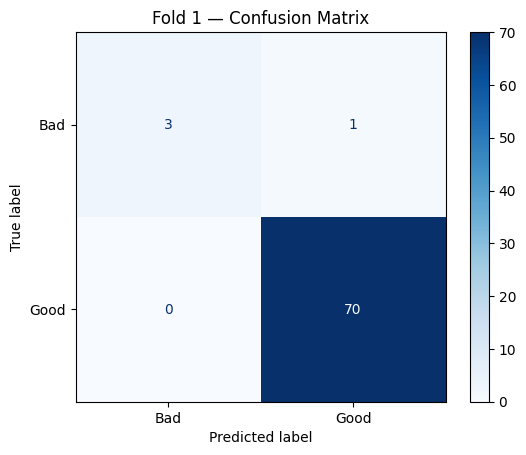

F1 Score: 0.9250253292806484
Pearson correlation: 0.8098875315544045



Fold 1
MAE : 125.05118507179054
RMSE: 191.75169851957799
R²  : 0.6144540458153237


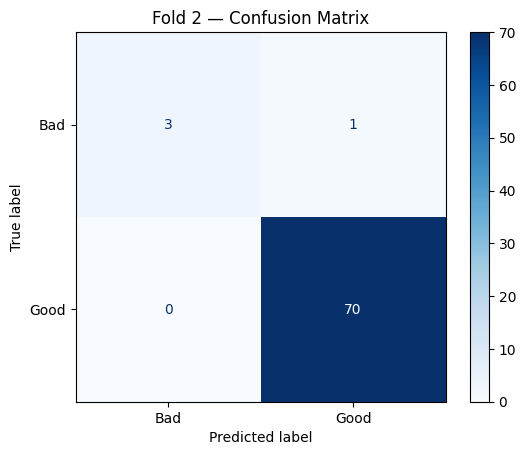

F1 Score: 0.9250253292806484
Pearson correlation: 0.7924230700751439



Fold 2
MAE : 131.6482177734375
RMSE: 280.3468085292048
R²  : 0.7079382636374756


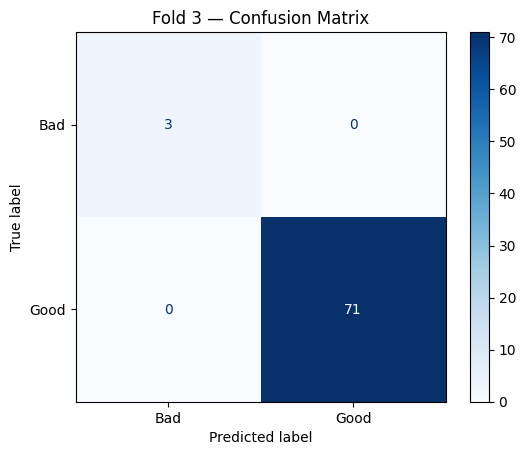

F1 Score: 1.0
Pearson correlation: 0.8197580043440381



Fold 3
MAE : 118.82558791701858
RMSE: 192.6250557085354
R²  : 0.818124598039089


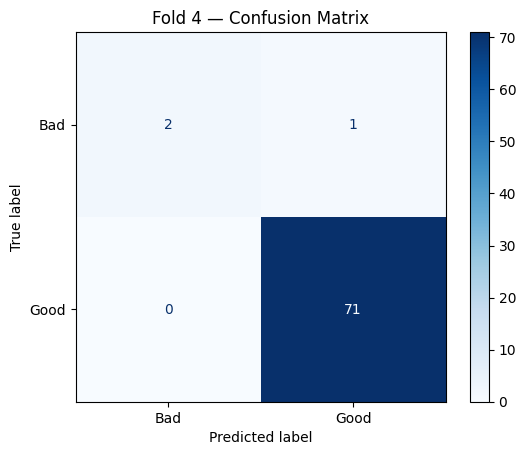

F1 Score: 0.8965034965034966
Pearson correlation: 0.8276826206558571



Fold 4
MAE : 114.95131308065882
RMSE: 151.11241982875364
R²  : 0.7061740859359192


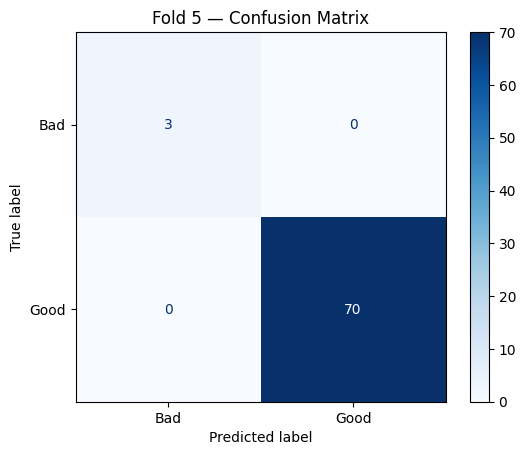

F1 Score: 1.0
Pearson correlation: 0.8202227873927925



Fold 5
MAE : 105.3911942155394
RMSE: 163.20004439742493
R²  : 0.7005446275477147


In [ ]:
cross_df = pd.read_csv("data/train_dev_data.csv")
target_column_regression = "PullTest (N)" 

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mean_list = []
mae_list = []
rmse_list = []
R2_list = []

for fold, (train_index, val_index) in enumerate(skf.split(cross_df["Sample ID"], cross_df["Category"])):
    x_tr, y_tr = get_features_and_target(cross_df.iloc[train_index], target_column_class) 
    x_val, y_val = get_features_and_target(cross_df.iloc[val_index], target_column_class)
    x_tr_nug, y_tr_nug = get_features_and_target(cross_df.iloc[train_index], target_column_nugget) 
    x_val_nug, y_val_nug = get_features_and_target(cross_df.iloc[val_index], target_column_nugget)
    x_train_regression, y_train_regression= get_features_and_target( cross_df.iloc[train_index], target_column_regression ) 
    x_validation_regression, y_val_regression= get_features_and_target( cross_df.iloc[val_index], target_column_regression ) 



    #Nugget estimation
    regressor_nug = TabPFNRegressor()
    regressor_nug.fit(x_tr_nug,y_tr_nug)

    predictions_nugget_train = regressor_nug.predict(x_tr_nug)
    predictions_nugget_dev = regressor_nug.predict(x_val_nug)

    #Classification
    classifier = TabPFNClassifier()
    classifier.fit(x_tr,y_tr)

    predictions_class_train = classifier.predict(x_tr)
    predictions_class_dev = classifier.predict(x_val)

    # Plot classification results for this fold
    plot_visualizer_classification(
        y_true=y_val,
        y_pred=predictions_class_dev,
        class_labels=["Bad", "Good"],
        title=f"Fold {fold+1} — Confusion Matrix"
    )


    x_train_regression.loc[:, "Physical_Inference"] = compute_pullforces(x_train_regression, y_train_regression, predictions_class_train, predictions_nugget_train) 
    x_validation_regression.loc[:, "Physical_Inference"] = compute_pullforces(x_validation_regression, y_val_regression, predictions_class_dev, predictions_nugget_dev)
    
    regressor = TabPFNRegressor()
    regressor.fit(x_train_regression, y_train_regression)

    # Predict on the test set
    predictions_regression_dev = regressor.predict(x_validation_regression)

    mae  = mean_absolute_error(y_val_regression, predictions_regression_dev)
    rmse = np.sqrt(mean_squared_error(y_val_regression, predictions_regression_dev))
    R2   = r2_score(y_val_regression, predictions_regression_dev)
    f1 = f1_score(y_val, predictions_class_dev, average="macro")

    mae_list.append(mae) 
    rmse_list.append(rmse) 
    R2_list.append(R2)
    mean_list.append(f1)

    corr = np.corrcoef(x_train_regression["Physical_Inference"], y_train_regression)[0,1] 
    print(f"Pearson correlation (Physics vs True PullForce): {corr:.4f}")


    # Categories
    categories= cross_df.iloc[val_index]["Category"].values

    plot_visualizer(
        true_vals=y_val_regression,
        pred_vals=predictions_regression_dev,
        categories=categories,
        title=f"Fold {fold+1}: True vs Prediction (TabPFN) by Category"
    )

    print(f"\nFold {fold+1}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", R2)

mae_mean = np.mean(mae_list) 
rmse_mean = np.mean(rmse_list) 
R2_mean = np.mean(R2_list) 
f1_mean = np.mean(mean_list) 

In [19]:
# Final Evaluation over all Folds

print("F1 Score:", f1_mean)
print(f"MAE:  {mae_mean:.2f}")
print(f"RMSE: {rmse_mean:.2f}")
print(f"R²:   {R2_mean:.2f}")

F1 Score: 0.9493108310129585
MAE:  119.17
RMSE: 195.81
R²:   0.71
